<a href="https://colab.research.google.com/github/caffein1371/Carrier-Owl/blob/master/atma1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
!apt-get -y install fonts-ipafont

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-ipafont is already the newest version (00303-21ubuntu1).
0 upgraded, 0 newly installed, 0 to remove and 29 not upgraded.


In [ ]:
!apt-get -y install fonts-ipafont-gothic

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-ipafont-gothic is already the newest version (00303-21ubuntu1).
0 upgraded, 0 newly installed, 0 to remove and 29 not upgraded.


In [ ]:
!fc-list | grep "IPA"

/usr/share/fonts/opentype/ipafont-mincho/ipam.ttf: IPAMincho,IPA明朝:style=Regular
/usr/share/fonts/opentype/ipafont-gothic/ipagp.ttf: IPAPGothic,IPA Pゴシック:style=Regular
/usr/share/fonts/opentype/ipafont-mincho/ipamp.ttf: IPAPMincho,IPA P明朝:style=Regular
/usr/share/fonts/opentype/ipafont-gothic/ipag.ttf: IPAGothic,IPAゴシック:style=Regular
/usr/share/fonts/truetype/fonts-japanese-mincho.ttf: IPAMincho,IPA明朝:style=Regular
/usr/share/fonts/truetype/fonts-japanese-gothic.ttf: IPAGothic,IPAゴシック:style=Regular


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# フォントのパスを指定
font_path = "/usr/share/fonts/opentype/ipafont-gothic/ipag.ttf"  # ここを適宜変更
font_prop = fm.FontProperties(fname=font_path)

# Matplotlib のデフォルトフォントを設定
plt.rcParams["font.family"] = font_prop.get_name()

print(f"使用フォント: {font_prop.get_name()}")  # どのフォントが設定されたか確認


使用フォント: IPAGothic


# EDA

In [ ]:
#オンライン EC サイト上の購買ログデータです。オフライン購買データ (train_session.csv / train_log.csv 他) とユーザー ID や購入セッション ID で紐づかないことに注意してください。
ec_df = pd.read_csv('/content/drive/MyDrive/atma/ec_log.csv')
#商品を一意に特定することができるコード (jan code) に対して、その商品の属性を記載しているデータです。
jan_df = pd.read_csv('/content/drive/MyDrive/atma/jan.csv')
#提出データの情報
test_session_df = pd.read_csv('/content/drive/MyDrive/atma/test_session.csv')
#学習期間の完全なオフライン購買データ。どの購入セッションで何を何円で何個かったか、の情報が記入されています
train_log_df = pd.read_csv('/content/drive/MyDrive/atma/train_log.csv')
#学習・テスト期間の購入セッションのメタ情報。学習期間とテスト期間は日付で分割されています。 2024-10-31 までが学習期間、それ以降がテスト期間です。
train_session_df = pd.read_csv('/content/drive/MyDrive/atma/train_session.csv')

train_target_df = pd.read_csv('/content/drive/MyDrive/atma/train_target.csv')

<ipython-input-6-b106b868f3a2>:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  ec_df = pd.read_csv('/content/drive/MyDrive/atma/ec_log.csv')


In [ ]:
train_session_df

,session_id,売上日,時刻,店舗名,年代,性別,顧客CD
0,3VrcoHzNbhVjwWry8bprTk,2024-07-01,0,つくば,20代,不明,9545f047bcc38513f1bf9d420b615bac99f9bcd17f43b6...
1,2BQUMmbDbCffCzmyCmJWXM,2024-07-01,0,つくば,20代,不明,a8caaca05647788262c55ae79b3c6ce4a99c87cab7667e...
2,Bbi8hQdtC3CCJxULJYCE9F,2024-07-01,0,つくば,20代,女性,33c89af908f24a3189312289978d1c950c219296c1f671...
3,7zecHQC6svwsdprayEJCfR,2024-07-01,0,つくば,20代,女性,395e3a5c2d0c006e619e8196e310e707feddaebae43a8c...
4,Dr2ky5Hdr8odb2uJQth8Hc,2024-07-01,0,つくば,20代,女性,ed59f7160f6b18c34a510d2ea179e39d3ea3f80f05be34...
...,...,...,...,...,...,...,...
2120546,3z9pZTJPwY3b29rJV8Jqfc,2024-10-31,23,門司店,60代,男性,34357aecb2373462e0a53d6ac425da586696588db17646...
2120547,8sPiNmDQMay7K8bDpZNGvR,2024-10-31,23,門司店,60代,男性,5cc57726b7fe4f0bff6e37a58267d2dfdba75341a59c19...
2120548,TEo9tKEMw5kLHCf55sRzvC,2024-10-31,23,門司店,60代,男性,c2820a47c280430c2a98507a1622ac0484a0888bb8740d...
2120549,MnBpN8RcoQMWZB3g24Ew3w,2024-10-31,23,門司店,60代,男性,cd0db4dc4170784d964e636b04cf4c64efc8ce410e3357...


In [ ]:
test_session_df.head()

,session_id,売上日,時刻,店舗名,年代,性別,顧客CD
0,222qahkdkra4b7isEosZ5z,2024-11-03,17,新宮店,40代,女性,c419920a6386b340b97b756bd8e8a55ec302af1b46f0b1...
1,223SvE3mDckZWaFKc4Ezmz,2024-11-01,17,門司店,80代以上,女性,041b2b2aefd6357d65f46a7c2c81b1b2895cefe6aa7a14...
2,224ZtFbG25byUwByo7s5Cz,2024-11-07,11,新宮店,70代,男性,747f2ef45b420c75d34201589349569b546c36adcb89eb...
3,227xpGcbQNAbpdP5LsYbGw,2024-11-22,8,日田店,60代,女性,f6015f2951f94e6b23a39ee33e659b8e1d755e81603c49...
4,2287s338C7P9qCcFbzLxSY,2024-11-09,15,門司店,60代,男性,00b7ce1ab255befbe9f76690044a8485d0d8e5704deb2c...


In [ ]:
train_target_df

,チョコレート,ビール,ヘアケア,米（5㎏以下）
0,0,0,0,0
1,0,0,0,0
2,0,0,0,0
3,0,0,0,0
4,0,0,0,0
...,...,...,...,...
2120546,0,0,0,0
2120547,0,0,0,0
2120548,0,0,0,0
2120549,0,0,0,0


In [ ]:
jan_df.head()

,JAN,ディビジョン,ライン,部門,カテゴリ名,商品名,規格,ブランド
0,272322,カスタマー,カスタマー,たばこ,紙巻たばこ,ｸｰﾙ･ﾏｲﾙﾄﾞFKﾎﾞｯｸｽ,XP2756,BAT
1,1231039,カスタマー,カスタマー,たばこ,紙巻たばこ,ｳｨﾝｽﾄﾝ･ﾌｨﾙﾀｰ,XP1470,JT
2,2721523,カスタマー,カスタマー,たばこ,紙巻たばこ,ｸｰﾙ･ﾌﾞｰｽﾄﾌﾚｯｼｭ8･ﾎﾞｯｸｽ,P3273,ｸ-ﾙ
3,2723220,カスタマー,カスタマー,たばこ,紙巻たばこ,ｸｰﾙ･ﾏｲﾙﾄﾞ･FKﾎﾞｯｸｽ,P2756,ｸ-ﾙ
4,2725228,カスタマー,カスタマー,たばこ,紙巻たばこ,ｸｰﾙ･FKﾎﾞｯｸｽ,P2619,ｸ-ﾙ


In [ ]:
from IPython.display import display
category_counts = jan_df["カテゴリ名"].value_counts()
print(category_counts.to_string())

カテゴリ名
トップス                6299
ボトムス                3486
ｾﾙﾌﾌﾞﾗﾝﾄﾞﾒｰｷｬｯﾌﾟ    2512
メンズトップス             2259
レディーストップス           2089
学用品                 1971
ヘアケア                1854
アウター                1722
筆記                  1653
レディースソックス           1579
単品メイク               1529
事務用品                1218
釣り具用品               1013
スキンケア               1001
女性頭髪                 992
メンズボトム               986
シーズン                 953
ヘアカラー                923
芳香消臭                 919
猫ウェット                918
メンズビューティ             913
ランジェリー＆ファンデーション      829
和洋菓子                 805
健康食品                 791
メンズソックス              747
菓子パン                 742
入浴剤                  721
芳香剤HC                715
メンズスポーツシューズ          714
エギ・ルアー               713
犬猫生活用品               673
ｶｳﾝｾﾘﾝｸﾞ化粧品          665
未登録等その他              637
珍味                   632
季節                   623
犬スナック                620
柔軟剤                  592
食器                   591
レディーススポーツシューズ        588
スナック               

In [ ]:
#chocolate
chocolate_jan =jan_df.loc[jan_df["カテゴリ名"] == "チョコレート", "JAN"]
print(chocolate_jan)
#ビール
bear_jan =jan_df.loc[jan_df["カテゴリ名"] == "ビール", "JAN"]
print(bear_jan)
#ヘアケア
haircare_jan =jan_df.loc[jan_df["カテゴリ名"] == "ヘアケア", "JAN"]
print(haircare_jan)
#ライス
rice_jan =jan_df.loc[jan_df["カテゴリ名"] == "米（5㎏以下）", "JAN"]
print(rice_jan)

531            49279825
1069        34000018758
1070        34000134113
1071        34000134311
1072        34000140589
              ...      
117344    4932515029596
119323    4969244505022
122120    6291003632792
124207    4580346092304
124526    4901005517660
Name: JAN, Length: 537, dtype: int64
454            47478619
704            49575330
705            49575491
1024           49893588
10125     4535659001185
              ...      
124525    4901004063106
124573    4901411511214
124685    4901777414587
124718    4901880931155
124719    4901880931261
Name: JAN, Length: 479, dtype: int64
5725      4513574012752
5726      4513574012769
5727      4513574014152
5728      4513574014169
5729      4513574015005
              ...      
126262    4971710541076
126482    4975302143044
126694    4981747077653
126695    4981747080813
127050    8809700493219
Name: JAN, Length: 1854, dtype: int64
5040      4510181070151
5041      4510181070359
5043      4510181070656
5045      4510181072612


In [ ]:
# フラグ列を作成
flag_df2 =pd.DataFrame()
flag_df2["choco_flag"] = train_log_df["JAN"].isin(chocolate_jan).astype(int)
flag_df2["bear_flag"] = train_log_df["JAN"].isin(bear_jan).astype(int)
flag_df2["haircare_flag"] = train_log_df["JAN"].isin(haircare_jan).astype(int)
flag_df2["rice_flag"] = train_log_df["JAN"].isin(rice_jan).astype(int)
# 結果を表示
print(flag_df2)

In [ ]:
# フラグ列を作成
flag_df =train_log_df.copy()
flag_df["choco_flag"] = train_log_df["JAN"].isin(chocolate_jan).astype(int)
flag_df["bear_flag"] = train_log_df["JAN"].isin(bear_jan).astype(int)
flag_df["haircare_flag"] = train_log_df["JAN"].isin(haircare_jan).astype(int)
flag_df["rice_flag"] = train_log_df["JAN"].isin(rice_jan).astype(int)
# 結果を表示
print(flag_df)

                      session_id            JAN  売上数量  売上金額  値割数量  値割金額  \
0         2222WjCzgbd2oEWF5AmrqQ  4522646193879     1   219     0     0   
1         2222WjCzgbd2oEWF5AmrqQ  4522646735680     1   199     0     0   
2         2222WjCzgbd2oEWF5AmrqQ  4901340082946     1    79     0     0   
3         2222WjCzgbd2oEWF5AmrqQ  4901516013682     2   238     0     0   
4         2222WjCzgbd2oEWF5AmrqQ  4901626025902     1    99     0     0   
...                          ...            ...   ...   ...   ...   ...   
20742884  oZEpwztdP4tzJc8i2BKYnw  4522646835892     1    79     0     0   
20742885  oZEpwztdP4tzJc8i2BKYnw  4901577020650     1   179     0     0   
20742886  oZEpwztdP4tzJc8i2BKYnw  4901577085307     1   269     0     0   
20742887  oZEpwztdP4tzJc8i2BKYnw  4902560310147     1   229     0     0   
20742888  oZEpwztdP4tzJc8i2BKYnw  4903301353218     1   499     0     0   

          choco_flag  bear_flag  haircare_flag  rice_flag  
0                  0          0        

In [ ]:
# session_idごとのチョコフラグを作成
session_flags = flag_df.groupby("session_id")["choco_flag"].max().reset_index()

# 顧客データとマージ
df_merged = train_session_df.merge(session_flags, on="session_id", how="left")
# NaNを0に変換（チョコを買っていないセッションは0）
df_merged["choco_flag"] = df_merged["choco_flag"].fillna(0).astype(int)

# session_idごとのbearフラグを作成
session_flags = flag_df.groupby("session_id")["bear_flag"].max().reset_index()
# 顧客データとマージ
df_merged = df_merged.merge(session_flags, on="session_id", how="left")
# NaNを0に変換（チョコを買っていないセッションは0）
df_merged["bear_flag"] = df_merged["bear_flag"].fillna(0).astype(int)

# session_idごとのhaircareフラグを作成
session_flags = flag_df.groupby("session_id")["haircare_flag"].max().reset_index()
# 顧客データとマージ
df_merged = df_merged.merge(session_flags, on="session_id", how="left")
# NaNを0に変換（チョコを買っていないセッションは0）
df_merged["haircare_flag"] = df_merged["haircare_flag"].fillna(0).astype(int)

# session_idごとのhaircareフラグを作成
session_flags = flag_df.groupby("session_id")["rice_flag"].max().reset_index()
# 顧客データとマージ
df_merged = df_merged.merge(session_flags, on="session_id", how="left")
# NaNを0に変換（チョコを買っていないセッションは0）
df_merged["rice_flag"] = df_merged["rice_flag"].fillna(0).astype(int)


# 結果を表示
print(df_merged)

                     session_id         売上日  時刻  店舗名   年代  性別  \
0        3VrcoHzNbhVjwWry8bprTk  2024-07-01   0  つくば  20代  不明   
1        2BQUMmbDbCffCzmyCmJWXM  2024-07-01   0  つくば  20代  不明   
2        Bbi8hQdtC3CCJxULJYCE9F  2024-07-01   0  つくば  20代  女性   
3        7zecHQC6svwsdprayEJCfR  2024-07-01   0  つくば  20代  女性   
4        Dr2ky5Hdr8odb2uJQth8Hc  2024-07-01   0  つくば  20代  女性   
...                         ...         ...  ..  ...  ...  ..   
2120546  3z9pZTJPwY3b29rJV8Jqfc  2024-10-31  23  門司店  60代  男性   
2120547  8sPiNmDQMay7K8bDpZNGvR  2024-10-31  23  門司店  60代  男性   
2120548  TEo9tKEMw5kLHCf55sRzvC  2024-10-31  23  門司店  60代  男性   
2120549  MnBpN8RcoQMWZB3g24Ew3w  2024-10-31  23  門司店  60代  男性   
2120550  5HERaELSaHymuDXNKg5xu9  2024-10-31  23  門司店   不明  不明   

                                                      顧客CD  choco_flag  \
0        9545f047bcc38513f1bf9d420b615bac99f9bcd17f43b6...           0   
1        a8caaca05647788262c55ae79b3c6ce4a99c87cab7667e...           0 

In [ ]:
# session_idごとのチョコフラグを作成
session_flags = flag_df.groupby("session_id")["choco_flag"].max().reset_index()

# 顧客データとマージ
df_merged = test_session_df.merge(session_flags, on="session_id", how="left")
# NaNを0に変換（チョコを買っていないセッションは0）
df_merged["choco_flag"] = df_merged["choco_flag"].fillna(0).astype(int)

# session_idごとのbearフラグを作成
session_flags = flag_df.groupby("session_id")["bear_flag"].max().reset_index()
# 顧客データとマージ
df_merged = df_merged.merge(session_flags, on="session_id", how="left")
# NaNを0に変換（チョコを買っていないセッションは0）
df_merged["bear_flag"] = df_merged["bear_flag"].fillna(0).astype(int)

# session_idごとのhaircareフラグを作成
session_flags = flag_df.groupby("session_id")["haircare_flag"].max().reset_index()
# 顧客データとマージ
df_merged = df_merged.merge(session_flags, on="session_id", how="left")
# NaNを0に変換（チョコを買っていないセッションは0）
df_merged["haircare_flag"] = df_merged["haircare_flag"].fillna(0).astype(int)

# session_idごとのhaircareフラグを作成
session_flags = flag_df.groupby("session_id")["rice_flag"].max().reset_index()
# 顧客データとマージ
df_merged = df_merged.merge(session_flags, on="session_id", how="left")
# NaNを0に変換（チョコを買っていないセッションは0）
df_merged["rice_flag"] = df_merged["rice_flag"].fillna(0).astype(int)


# 結果を表示
print(df_merged)

                    session_id         売上日  時刻  店舗名     年代  性別  \
0       222qahkdkra4b7isEosZ5z  2024-11-03  17  新宮店    40代  女性   
1       223SvE3mDckZWaFKc4Ezmz  2024-11-01  17  門司店  80代以上  女性   
2       224ZtFbG25byUwByo7s5Cz  2024-11-07  11  新宮店    70代  男性   
3       227xpGcbQNAbpdP5LsYbGw  2024-11-22   8  日田店    60代  女性   
4       2287s338C7P9qCcFbzLxSY  2024-11-09  15  門司店    60代  男性   
...                        ...         ...  ..  ...    ...  ..   
121410  oZ8CYz7tmRnVAszZpzwVEg  2024-11-02  17  新宮店    40代  不明   
121411  oZ8zCvKGd7RVMNVffZQfmg  2024-11-05  12  日田店    70代  女性   
121412  oZCeMk4vt4vQeebUutAVV7  2024-11-02  11  日田店    50代  女性   
121413  oZCuuEtwGyNFZvcxJiAZY8  2024-11-06  16  日田店    50代  女性   
121414  oZCzrQvSBeFAAs6usxaB37  2024-11-03  20  門司店    60代  男性   

                                                     顧客CD  choco_flag  \
0       c419920a6386b340b97b756bd8e8a55ec302af1b46f0b1...           0   
1       041b2b2aefd6357d65f46a7c2c81b1b2895cefe6aa7a14...    

In [ ]:
df_merged['haircare_flag'].mean()

np.float64(0.0)

In [ ]:
df_merged['haircare_flag'].mean()

np.float64(0.02813608349905284)

In [ ]:
train_session_df.head()

,session_id,売上日,時刻,店舗名,年代,性別,顧客CD
0,3VrcoHzNbhVjwWry8bprTk,2024-07-01,0,つくば,20代,不明,9545f047bcc38513f1bf9d420b615bac99f9bcd17f43b6...
1,2BQUMmbDbCffCzmyCmJWXM,2024-07-01,0,つくば,20代,不明,a8caaca05647788262c55ae79b3c6ce4a99c87cab7667e...
2,Bbi8hQdtC3CCJxULJYCE9F,2024-07-01,0,つくば,20代,女性,33c89af908f24a3189312289978d1c950c219296c1f671...
3,7zecHQC6svwsdprayEJCfR,2024-07-01,0,つくば,20代,女性,395e3a5c2d0c006e619e8196e310e707feddaebae43a8c...
4,Dr2ky5Hdr8odb2uJQth8Hc,2024-07-01,0,つくば,20代,女性,ed59f7160f6b18c34a510d2ea179e39d3ea3f80f05be34...


In [ ]:
train_log_df.head()

,session_id,JAN,売上数量,売上金額,値割数量,値割金額
0,2222WjCzgbd2oEWF5AmrqQ,4522646193879,1,219,0,0
1,2222WjCzgbd2oEWF5AmrqQ,4522646735680,1,199,0,0
2,2222WjCzgbd2oEWF5AmrqQ,4901340082946,1,79,0,0
3,2222WjCzgbd2oEWF5AmrqQ,4901516013682,2,238,0,0
4,2222WjCzgbd2oEWF5AmrqQ,4901626025902,1,99,0,0


In [ ]:
test_session_df.head()

,session_id,売上日,時刻,店舗名,年代,性別,顧客CD
0,222qahkdkra4b7isEosZ5z,2024-11-03,17,新宮店,40代,女性,c419920a6386b340b97b756bd8e8a55ec302af1b46f0b1...
1,223SvE3mDckZWaFKc4Ezmz,2024-11-01,17,門司店,80代以上,女性,041b2b2aefd6357d65f46a7c2c81b1b2895cefe6aa7a14...
2,224ZtFbG25byUwByo7s5Cz,2024-11-07,11,新宮店,70代,男性,747f2ef45b420c75d34201589349569b546c36adcb89eb...
3,227xpGcbQNAbpdP5LsYbGw,2024-11-22,8,日田店,60代,女性,f6015f2951f94e6b23a39ee33e659b8e1d755e81603c49...
4,2287s338C7P9qCcFbzLxSY,2024-11-09,15,門司店,60代,男性,00b7ce1ab255befbe9f76690044a8485d0d8e5704deb2c...


In [ ]:
jan_df.head()

,JAN,ディビジョン,ライン,部門,カテゴリ名,商品名,規格,ブランド
0,272322,カスタマー,カスタマー,たばこ,紙巻たばこ,ｸｰﾙ･ﾏｲﾙﾄﾞFKﾎﾞｯｸｽ,XP2756,BAT
1,1231039,カスタマー,カスタマー,たばこ,紙巻たばこ,ｳｨﾝｽﾄﾝ･ﾌｨﾙﾀｰ,XP1470,JT
2,2721523,カスタマー,カスタマー,たばこ,紙巻たばこ,ｸｰﾙ･ﾌﾞｰｽﾄﾌﾚｯｼｭ8･ﾎﾞｯｸｽ,P3273,ｸ-ﾙ
3,2723220,カスタマー,カスタマー,たばこ,紙巻たばこ,ｸｰﾙ･ﾏｲﾙﾄﾞ･FKﾎﾞｯｸｽ,P2756,ｸ-ﾙ
4,2725228,カスタマー,カスタマー,たばこ,紙巻たばこ,ｸｰﾙ･FKﾎﾞｯｸｽ,P2619,ｸ-ﾙ


In [ ]:
train_session_df.head()

,session_id,売上日,時刻,店舗名,年代,性別,顧客CD
0,3VrcoHzNbhVjwWry8bprTk,2024-07-01,0,つくば,20代,不明,9545f047bcc38513f1bf9d420b615bac99f9bcd17f43b6...
1,2BQUMmbDbCffCzmyCmJWXM,2024-07-01,0,つくば,20代,不明,a8caaca05647788262c55ae79b3c6ce4a99c87cab7667e...
2,Bbi8hQdtC3CCJxULJYCE9F,2024-07-01,0,つくば,20代,女性,33c89af908f24a3189312289978d1c950c219296c1f671...
3,7zecHQC6svwsdprayEJCfR,2024-07-01,0,つくば,20代,女性,395e3a5c2d0c006e619e8196e310e707feddaebae43a8c...
4,Dr2ky5Hdr8odb2uJQth8Hc,2024-07-01,0,つくば,20代,女性,ed59f7160f6b18c34a510d2ea179e39d3ea3f80f05be34...


In [ ]:
ec_df.head()

,USER_ID,PURCHASED_AT,EC_SITE_NAME,UNIT_PRICE,AMOUNT,AMOUNT_WB,TOTAL_PRICE,TOTAL_PRICE_WB,ITEM_NAME,ITEM_URL,JAN,GENRE,GENDER_NAME,AGE_CATEGORY,FURUSATO_FLG,RAKUTEN_USER,WEIGHT_BACK_VALUE
0,74aa584eddc336921bdac47fc6fe1ce970cfaeef3f2883...,2024-07-01 00:00:04+09:00,Rakuten,2699.0,1.0,0.465978,2699.0,1257.673359,"『店内全品ポイント2倍アップ！30日限定！09:00〜23:59 』＼クーポン利用で1,69...",https://item.rakuten.co.jp/5000cshop/5zkdk-1/,NaN,NaN,女性,30代,0,1,0.465978
1,dd98b74fccc9331808a9e97cf56f02963fdd6cc2d9aad9...,2024-07-01 00:00:08+09:00,Rakuten,15000.0,1.0,0.906080,15000.0,13591.198129,【7/1限定★最大50％OFF！ほぼ全品に使えるクーポン配布中】炭八 福袋 2024 大袋の...,https://item.rakuten.co.jp/granire-plus/sumi-41/,NaN,日用品雑貨・文房具・手芸,男性,40代,0,1,0.906080
2,b078067564ee40e3813b95fad803cb9a2918bffc072b8e...,2024-07-01 00:00:09+09:00,Rakuten,1000.0,1.0,0.465978,1000.0,465.977532,漁師が作る鮭とば100g北海道産鮭とば 1000円ポッキリ 鮭トバ さけとば おつまみ【送料...,https://item.rakuten.co.jp/kitanomachi/saketob...,NaN,食品,女性,30代,0,1,0.465978
3,2812f2353d41a98f57e11c782bf6de57f1942447fa1f73...,2024-07-01 00:00:12+09:00,Amazon,NaN,1.0,0.800676,19250.0,15413.021242,NaN,NaN,NaN,NaN,男性,30代,0,0,0.800676
4,bdda88ef299d4feec04c86b75d5188ea2dde37a807e26e...,2024-07-01 00:00:12+09:00,Amazon,NaN,1.0,0.564774,2759.0,1558.210743,NaN,NaN,NaN,NaN,男性,20代,0,1,0.564774


In [ ]:
def create_session_feature(input_session_df: pd.DataFrame) -> pd.DataFrame:
    use_columns = [
        "時刻"
    ]

    return input_session_df[use_columns].copy()

In [ ]:
create_session_feature(train_session_df)

,時刻
0,0
1,0
2,0
3,0
4,0
...,...
2120546,23
2120547,23
2120548,23
2120549,23


In [ ]:
!pip install holidays

In [ ]:
import holidays
from datetime import datetime

def create_date_feature(input_session_df):
    jp_holidays = holidays.Japan(years=datetime.now().year)
    date = pd.to_datetime(input_session_df["売上日"])

    output_df = pd.DataFrame()

    def is_holiday(date):
      return date in jp_holidays


    #output_df["年"] = date.dt.year
    output_df["曜日"] = date.dt.dayofweek
    output_df["日"] = date.dt.day
    output_df["祝日"] = date.apply(is_holiday)

    return output_df

In [ ]:
create_date_feature(train_session_df)

,曜日,日,祝日
0,0,1,False
1,0,1,False
2,0,1,False
3,0,1,False
4,0,1,False
...,...,...,...
2120546,3,31,False
2120547,3,31,False
2120548,3,31,False
2120549,3,31,False


In [ ]:
input_df = train_session_df.copy()

# 性別がとりうる値を最初に決める
categories = train_session_df["性別"].unique()

# 列にカテゴリを指定して, 性別の種類ごとに存在していたら 1 しないと 0 のデータに変換
pd.get_dummies(input_df["性別"], columns=categories)

,不明,女性,男性
0,True,False,False
1,True,False,False
2,False,True,False
3,False,True,False
4,False,True,False
...,...,...,...
2120546,False,False,True
2120547,False,False,True
2120548,False,False,True
2120549,False,False,True


In [ ]:
def create_gender_feature(input_df):

    # 性別がとりうる値を最初に決める
    categories = train_session_df["性別"].unique()

    # 列にカテゴリを指定して, 性別の種類ごとに存在していたら 1 しないと 0 のデータに変換
    output_df = pd.get_dummies(input_df["性別"], columns=categories)

    return output_df

In [ ]:
create_gender_feature(test_session_df)

,不明,女性,男性
0,False,True,False
1,False,True,False
2,False,False,True
3,False,True,False
4,False,False,True
...,...,...,...
121410,True,False,False
121411,False,True,False
121412,False,True,False
121413,False,True,False


In [ ]:
def create_tenpo_feature(input_df):

    # 性別がとりうる値を最初に決める
    categories = train_session_df["店舗名"].unique()

    # 列にカテゴリを指定して, 性別の種類ごとに存在していたら 1 しないと 0 のデータに変換
    output_df = pd.get_dummies(input_df["店舗名"], columns=categories)

    return output_df

In [ ]:
create_tenpo_feature(test_session_df)

,つくば,新宮店,日田店,益浦店,福岡空,門司店
0,False,True,False,False,False,False
1,False,False,False,False,False,True
2,False,True,False,False,False,False
3,False,False,True,False,False,False
4,False,False,False,False,False,True
...,...,...,...,...,...,...
121410,False,True,False,False,False,False
121411,False,False,True,False,False,False
121412,False,False,True,False,False,False
121413,False,False,True,False,False,False


In [ ]:
def create_nendai_feature(input_df):

    # 性別がとりうる値を最初に決める
    categories = train_session_df["年代"].unique()

    # 列にカテゴリを指定して, 性別の種類ごとに存在していたら 1 しないと 0 のデータに変換
    output_df = pd.get_dummies(input_df["年代"], columns=categories)

    return output_df

In [ ]:
create_nendai_feature(test_session_df)

,10代以下,20代,30代,40代,50代,60代,70代,80代以上,不明
0,False,False,False,True,False,False,False,False,False
1,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...
121410,False,False,False,True,False,False,False,False,False
121411,False,False,False,False,False,False,True,False,False
121412,False,False,False,False,True,False,False,False,False
121413,False,False,False,False,True,False,False,False,False


In [ ]:
def create_flag_feature(input_df):

    # 性別がとりうる値を最初に決める
    categories = train_session_df["年代"].unique()

    # 列にカテゴリを指定して, 性別の種類ごとに存在していたら 1 しないと 0 のデータに変換
    output_df = pd.get_dummies(input_df["年代"], columns=categories)

    return output_df

In [ ]:
def create_feat_data(train_session_df, log_df):
    output_df = pd.DataFrame()
    for c in TARGET_COLUMNS:
        print(f"\t- start {c}")
        idx = jan_df["カテゴリ名"] == c
        target_jan = jan_df["JAN"][idx].values
        is_target = log_df["JAN"].isin(target_jan)

        # セッションごとに, 対象商品のレコードの売上個数を合計して
        total_amount_by_session = log_df[is_target].groupby("session_id")["売上数量"].sum()

        # 1 個以上購入があったセッションを positive (購入あり) セッションとみなし
        positive_sessions = total_amount_by_session[total_amount_by_session > 0].index

        # 学習用データのセッションと比較・含まれているとき 1 そうでないとき 0 になるようにする
        y_true = train_session_df["session_id"].isin(positive_sessions).astype(int)

        output_df[c] = y_true

    return output_df

In [ ]:
from typing import List
from contextlib import contextmanager
from time import time

# コードの実行時間を計測する便利関数
# https://github.com/nyk510/vivid/blob/master/vivid/utils.py
class Timer:
    def __init__(self, logger=None, format_str="{:.3f}[s]", prefix=None, suffix=None, sep=" "):

        if prefix: format_str = str(prefix) + sep + format_str
        if suffix: format_str = format_str + sep + str(suffix)
        self.format_str = format_str
        self.logger = logger
        self.start = None
        self.end = None

    @property
    def duration(self):
        if self.end is None:
            return 0
        return self.end - self.start

    def __enter__(self):
        self.start = time()

    def __exit__(self, exc_type, exc_val, exc_tb):
        self.end = time()
        out_str = self.format_str.format(self.duration)
        if self.logger:
            self.logger.info(out_str)
        else:
            print(out_str)

def build_feature(input_df: pd.DataFrame, feature_functions: List) -> pd.DataFrame:
    # 出力するデータフレームを空で用意して
    out_df = pd.DataFrame()

    print("start build features...")

    # 各特徴生成関数ごとで
    for func in feature_functions:

        with Timer(prefix=f"create {func.__name__}"):
            # 特徴量を作成し
            _df = func(input_df)

        # 横方向 (axis=1) にがっちゃんこ (concat) する
        out_df = pd.concat([out_df, _df], axis=1)

    return out_df

In [ ]:
functions = [
    create_session_feature,
    create_gender_feature,
    create_date_feature,
    create_tenpo_feature,
    create_nendai_feature,
]

In [ ]:
with Timer(prefix="build train..."):
    train_feat_df = build_feature(train_session_df, feature_functions=functions)

with Timer(prefix="build test..."):
    test_feat_df = build_feature(test_session_df, feature_functions=functions)

start build features...
create create_session_feature 0.018[s]
create create_gender_feature 0.267[s]
create create_date_feature 8.272[s]
create create_tenpo_feature 0.262[s]
create create_nendai_feature 0.246[s]
build train... 9.146[s]
start build features...
create create_session_feature 0.002[s]
create create_gender_feature 0.116[s]
create create_date_feature 0.619[s]
create create_tenpo_feature 0.115[s]
create create_nendai_feature 0.106[s]
build test... 0.967[s]


In [ ]:
assert train_feat_df.columns.equals(test_feat_df.columns)

In [ ]:
train_feat_df.head()

,時刻,不明,女性,男性,曜日,日,祝日,つくば,新宮店,日田店,...,門司店,10代以下,20代,30代,40代,50代,60代,70代,80代以上,不明
0,0,True,False,False,0,1,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
1,0,True,False,False,0,1,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
2,0,False,True,False,0,1,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
3,0,False,True,False,0,1,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
4,0,False,True,False,0,1,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False


# 正解ラベル

In [ ]:
TARGET_COLUMNS = ['チョコレート', 'ビール', 'ヘアケア', '米（5㎏以下）']

In [ ]:
# def create_target_data(train_session_df, log_df):
#     output_df = pd.DataFrame()
#     for c in TARGET_COLUMNS:
#         print(f"\t- start {c}")
#         idx = jan_df["カテゴリ名"] == c
#         target_jan = jan_df["JAN"][idx].values
#         is_target = log_df["JAN"].isin(target_jan)

#         # セッションごとに, 対象商品のレコードの売上個数を合計して
#         total_amount_by_session = log_df[is_target].groupby("session_id")["売上数量"].sum()

#         # 1 個以上購入があったセッションを positive (購入あり) セッションとみなし
#         positive_sessions = total_amount_by_session[total_amount_by_session > 0].index

#         # 学習用データのセッションと比較・含まれているとき 1 そうでないとき 0 になるようにする
#         y_true = train_session_df["session_id"].isin(positive_sessions).astype(int)

#         output_df[c] = y_true

#     return output_df

In [ ]:
def create_target_data(train_session_df, log_df, jan_df, threshold=1, price_threshold=None):
    output_df = pd.DataFrame()

    # 負の売上数量を削除（返品を除外）
    log_df = log_df[log_df["売上数量"] >= 0]

    for c in TARGET_COLUMNS:
        print(f"\t- start {c}")
        idx = jan_df["カテゴリ名"] == c
        target_jan = jan_df["JAN"][idx].values
        is_target = log_df["JAN"].isin(target_jan)

        # セッションごとの売上個数合計
        total_amount_by_session = log_df[is_target].groupby("session_id")["売上数量"].sum()

        # 売上金額のしきい値がある場合は、金額ベースのフィルタ
        if price_threshold is not None:
            total_sales_by_session = log_df[is_target].groupby("session_id")["売上金額"].sum()
            positive_sessions = total_sales_by_session[total_sales_by_session >= price_threshold].index
        else:
            positive_sessions = total_amount_by_session[total_amount_by_session >= threshold].index

        # 学習用データのセッションと比較
        y_true = train_session_df["session_id"].isin(positive_sessions).astype(int)

        output_df[c] = y_true

    return output_df

In [ ]:
with Timer(prefix="create target..."):
    target_df = create_target_data(train_session_df=train_session_df, log_df=train_log_df,jan_df=jan_df)

	- start チョコレート
	- start ビール
	- start ヘアケア
	- start 米（5㎏以下）
create target... 7.840[s]


In [ ]:
target_df.mean()

,0
チョコレート,0.068832
ビール,0.074139
ヘアケア,0.028059
米（5㎏以下）,0.019925


In [ ]:
from sklearn.model_selection import KFold

fold = KFold(n_splits=5, shuffle=True, random_state=510)
cv = list(fold.split(train_feat_df.values, target_df.iloc[:, 0].values))

In [ ]:
from sklearn.metrics import roc_auc_score
import lightgbm as lgbm

def fit_lgbm(X,
             y,
             cv,
             params: dict=None,
             verbose: int=50):
    """lightGBM を CrossValidation の枠組みで学習を行なう function"""

    # パラメータがないときは、空の dict で置き換える
    if params is None:
        params = {}

    models = []
    n_records = len(X)
    # training data の target と同じだけのゼロ配列を用意
    oof_pred = np.zeros((n_records, ), dtype=np.float32)

    for i, (idx_train, idx_valid) in enumerate(cv):
        # この部分が交差検証のところです。データセットを cv instance によって分割します
        # training data を trian/valid に分割
        x_train, y_train = X[idx_train], y[idx_train]
        x_valid, y_valid = X[idx_valid], y[idx_valid]

        clf = lgbm.LGBMClassifier(**params)

        with Timer(prefix="fit fold={} ".format(i)):
            clf.fit(x_train, y_train,
                    eval_set=[(x_valid, y_valid)],
                    callbacks=[lgbm.callback.early_stopping(stopping_rounds=100),
                      lgbm.log_evaluation(period=verbose),],)

        # 予測確率を出力してもらう
        pred_i = clf.predict_proba(x_valid)
        # output の形は shape = (n_samples, 2) になっていることに注意!
        y_pred_prob = pred_i[:, 1]

        oof_pred[idx_valid] = y_pred_prob
        models.append(clf)

        # 今回の指標の MAE で計算する
        score = roc_auc_score(y_valid, y_pred_prob, )
        print(f" - fold{i} - {score:.4f}")

    return oof_pred, models

In [ ]:
params = {
    # 目的関数. これの意味で最小となるようなパラメータを探します.
    # 今回は 0-1 問題なので, よく使われる binary を利用します
    "objective": "binary",

     # 学習率. 小さいほどなめらかな決定境界が作られて性能向上に繋がる場合が多いです、
    # がそれだけ木を作るため学習に時間がかかります
    "learning_rate": .1,

    # 木の最大数. early_stopping という枠組みで木の数は制御されるようにしていますのでとても大きい値を指定しておきます.
    "n_estimators": 10000,

    # 特徴重要度計算のロジック(後述)
    "importance_type": "gain",
    "random_state": 510,

    # ログがあまりに多いので少なめに.
    "verbose": -1
}
#futre work hypper parameter

In [ ]:
# 今回は予測対象が複数あるので for 文を使ってそれぞれの列に対して予測をしてくれるモデルを作ります.
results = []

for col_i in TARGET_COLUMNS:
    with Timer(prefix=f"column={col_i}"):
        oof, models = fit_lgbm(X=train_feat_df.values, y=target_df[col_i].values, cv=cv, params=params)

    results.append([oof, models])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Training until validation scores don't improve for 100 rounds
[50]	valid_0's binary_logloss: 0.244689
[100]	valid_0's binary_logloss: 0.244468
[150]	valid_0's binary_logloss: 0.244376
[200]	valid_0's binary_logloss: 0.24433
[250]	valid_0's binary_logloss: 0.244253
[300]	valid_0's binary_logloss: 0.244199
[350]	valid_0's binary_logloss: 0.244178
[400]	valid_0's binary_logloss: 0.244167
[450]	valid_0's binary_logloss: 0.244172
Early stopping, best iteration is:
[395]	valid_0's binary_logloss: 0.244164
fit fold=0  65.392[s]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 - fold0 - 0.6091


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 - fold3 - 0.6475


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Training until validation scores don't improve for 100 rounds
[50]	valid_0's binary_logloss: 0.0951459
[100]	valid_0's binary_logloss: 0.0949481
[150]	valid_0's binary_logloss: 0.0947687
[200]	valid_0's binary_logloss: 0.0946099
[250]	valid_0's binary_logloss: 0.0945006
[300]	valid_0's binary_logloss: 0.0944942
[350]	valid_0's binary_logloss: 0.09444
[400]	valid_0's binary_logloss: 0.094392
[450]	valid_0's binary_logloss: 0.0943599
[500]	valid_0's binary_logloss: 0.094357
[550]	valid_0's binary_logloss: 0.0943531
[600]	valid_0's binary_logloss: 0.0943714
Early stopping, best iteration is:
[515]	valid_0's binary_logloss: 0.0943485
fit fold=4  73.153[s]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 - fold4 - 0.6528
column=米（5㎏以下） 391.929[s]


In [ ]:
oof_df = pd.DataFrame()

for col_i, (oof, _) in zip(TARGET_COLUMNS, results):
    oof_df[col_i] = oof

In [ ]:
roc_auc_score(target_df.values, oof_df.values)

np.float64(0.6331765372862802)

In [ ]:
train_feat_df.head()

,時刻,不明,女性,男性,曜日,日,祝日,つくば,新宮店,日田店,...,門司店,10代以下,20代,30代,40代,50代,60代,70代,80代以上,不明
0,0,True,False,False,0,1,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
1,0,True,False,False,0,1,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
2,0,False,True,False,0,1,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
3,0,False,True,False,0,1,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
4,0,False,True,False,0,1,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False


In [ ]:
def visualize_importance(models, feat_train_df):
    """lightGBM の model 配列の feature importance を plot する
    CVごとのブレを boxen plot として表現します.

    args:
        models:
            List of lightGBM models
        feat_train_df:
            学習時に使った DataFrame
    """
    feature_importance_df = pd.DataFrame()
    for i, model in enumerate(models):
        _df = pd.DataFrame()
        _df["feature_importance"] = model.feature_importances_
        _df["column"] = feat_train_df.columns
        _df["fold"] = i + 1
        feature_importance_df = pd.concat([feature_importance_df, _df],
                                          axis=0, ignore_index=True)

    order = feature_importance_df.groupby("column")\
        .sum()[["feature_importance"]]\
        .sort_values("feature_importance", ascending=False).index[:50]

    fig, ax = plt.subplots(figsize=(8, max(6, len(order) * .25)))
    sns.boxenplot(data=feature_importance_df,
                  x="feature_importance",
                  y="column",
                  order=order,
                  ax=ax,
                  palette="viridis",
                  orient="h")
    ax.tick_params(axis="x", rotation=90)
    ax.set_title("Importance")
    ax.grid()
    fig.tight_layout()
    return fig, ax

<ipython-input-94-b58075a077f3>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=feature_importance_df,
<ipython-input-94-b58075a077f3>:35: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
<ipython-input-94-b58075a077f3>:35: UserWarning: Glyph 30007 (\N{CJK UNIFIED IDEOGRAPH-7537}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
<ipython-input-94-b58075a077f3>:35: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
<ipython-input-94-b58075a077f3>:35: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
<ipython-input-94-b58075a077f3>:35: UserWarning: Glyph 21051 (\N{CJK UNIFIED IDEOGRAPH-523B}) missing from font(s) DejaVu Sans.
  fig.tight_l

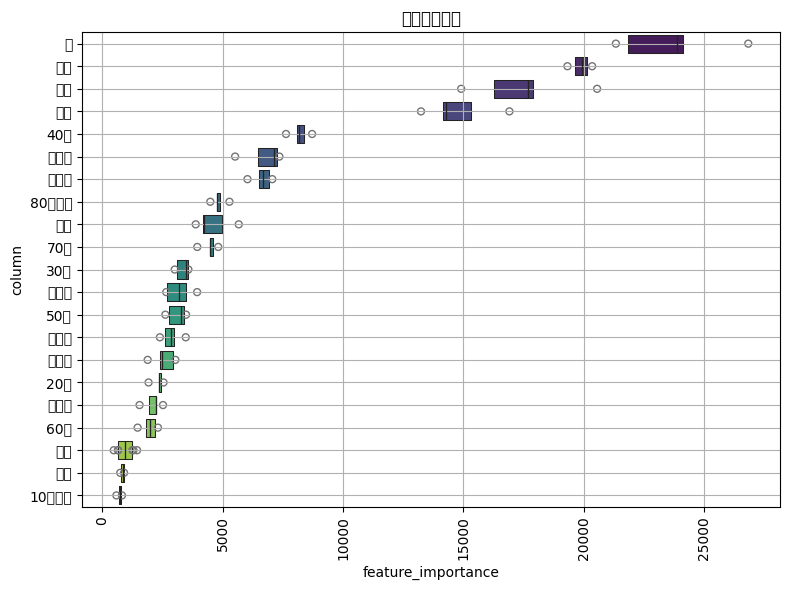

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12499 (\N{KATAKANA LETTER BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


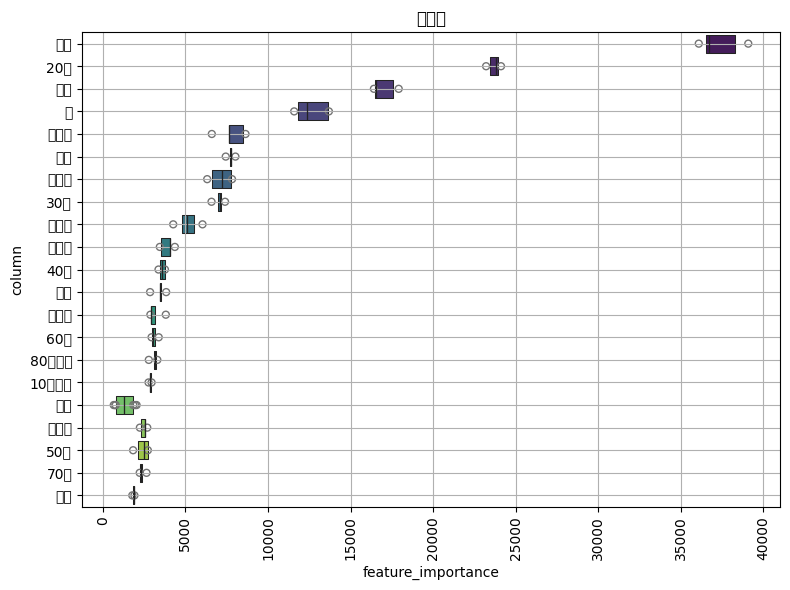

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12504 (\N{KATAKANA LETTER HE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12450 (\N{KATAKANA LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12465 (\N{KATAKANA LETTER KE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


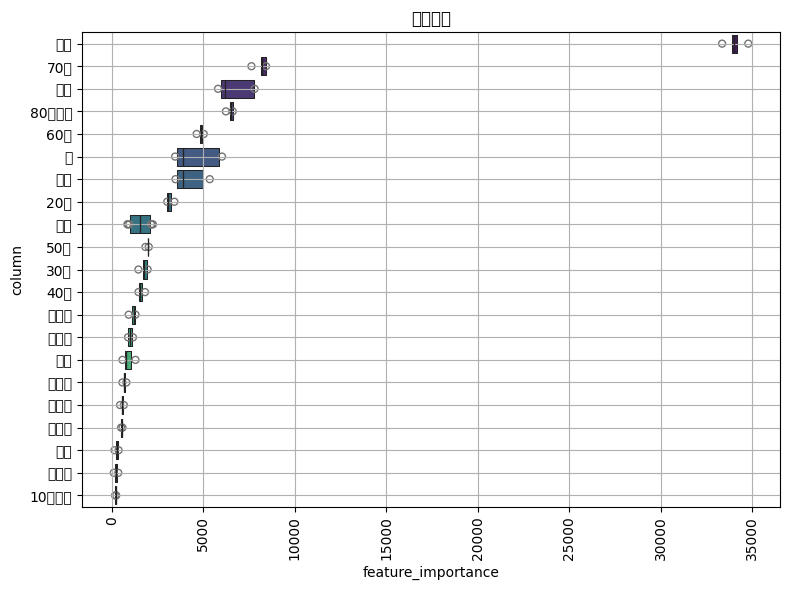

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 31859 (\N{CJK UNIFIED IDEOGRAPH-7C73}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 13199 (\N{SQUARE KG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


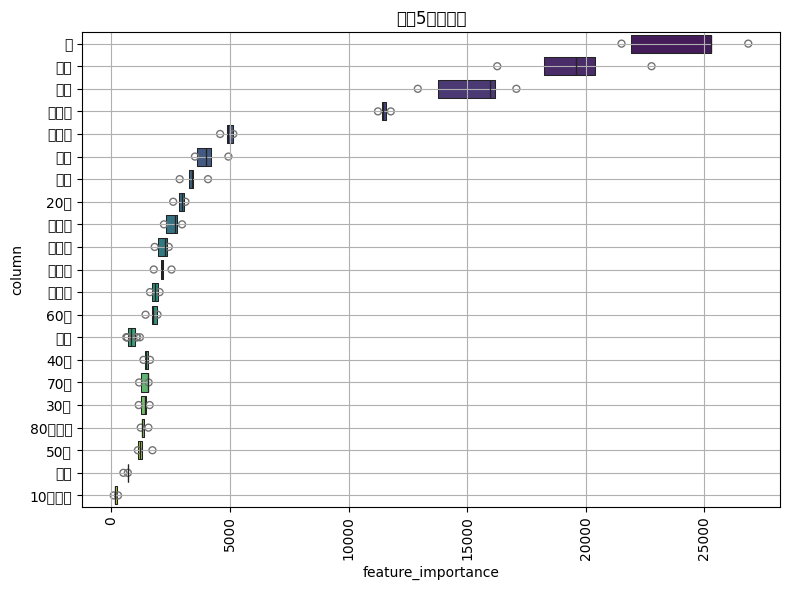

In [ ]:
for col_i, (oof, models) in zip(TARGET_COLUMNS, results):
    fig, ax = visualize_importance(models, train_feat_df)
    ax.set_title(col_i)

In [ ]:
submission_df = pd.DataFrame()

for col_i, (oof, models) in zip(TARGET_COLUMNS, results):
    predicts = [model.predict_proba(test_feat_df.values)[:, 1] for model in models]
    predict_i = np.array(predicts).mean(axis=0)

    submission_df[col_i] = predict_i

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

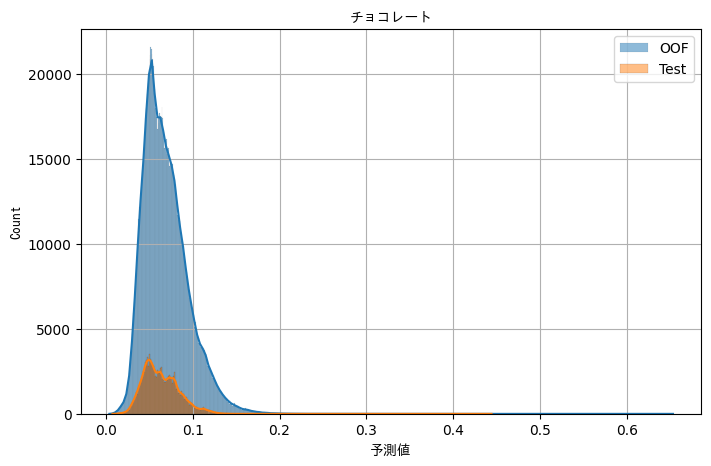

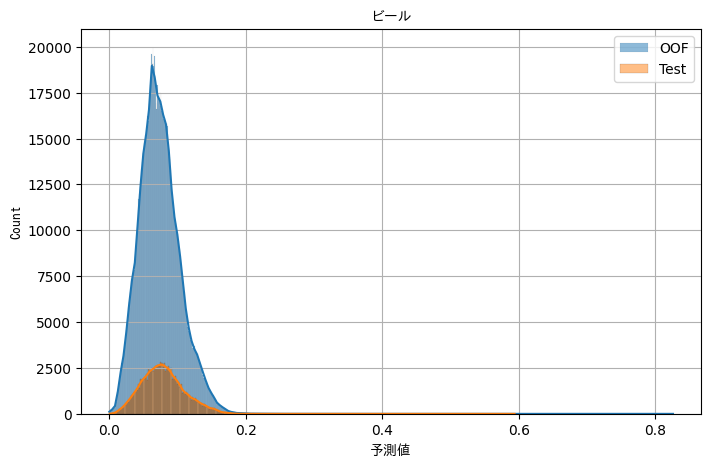

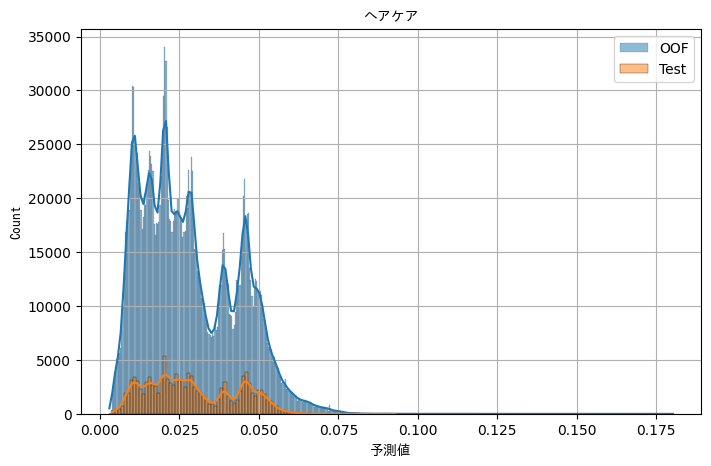

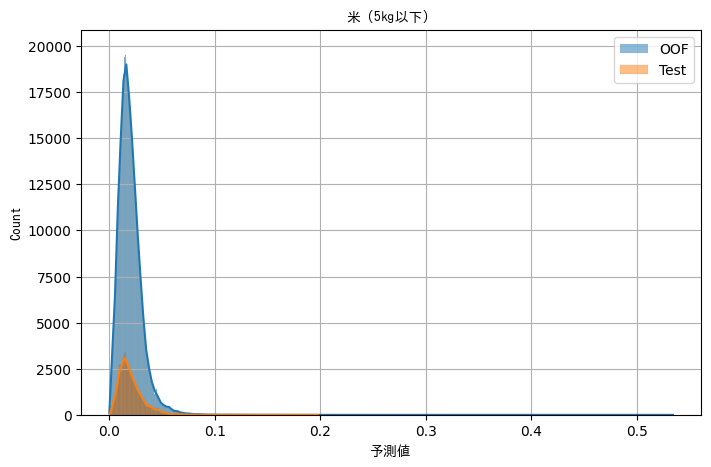

In [ ]:
for c in TARGET_COLUMNS:
    fig, ax = plt.subplots(figsize=(8, 5))

    sns.histplot(oof_df[c], ax=ax, label="OOF", kde=True)
    sns.histplot(submission_df[c], ax=ax, label="Test", kde=True)

    ax.set_xlabel("予測値", fontproperties=font_prop)  # x軸ラベルの文字化けを防ぐ
    ax.set_ylabel("Count", fontproperties=font_prop)  # y軸ラベルも設定
    ax.set_title(c, fontproperties=font_prop)  # 日本語タイトル対応
    ax.legend()
    ax.grid()

    plt.show()

In [ ]:
import os

In [ ]:
OUTPUT_DIR = "/content/drive/MyDrive/atma/tutorial_1"

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
submission_df.to_csv(os.path.join(OUTPUT_DIR, "#3__submission.csv"), index=False)

In [ ]:
rm -rf ~/.cache/matplotlib